# Tiling a spatial network: compact, volume-balanced partitions

Partitioning a spatial domain into contiguous regions of similar size is a common task in spatial analysis. Such partitions provide a natural way to perform local analyses, construct spatially resolved statistics, generate subnetworks, or divide large datasets into manageable regions for parallel computation. In Euclidean domains, this is often achieved by tessellating or tiling the underlying space.

For spatial networks, however, the problem is less straightforward. The domain is defined by the network edges rather than a continuous geometric region, so there is no natural notion of area or volume over which to construct a conventional tessellation. Instead, a useful partitioning algorithm should produce contiguous groups of nodes that each represent a similar amount of the underlying network while remaining spatially compact.

Although many graph partitioning and community detection algorithms exist, they are generally designed to maximise network modularity or minimise edge cuts, rather than balance the amount of network contained within each partition. Consequently, they do not typically produce partitions that resemble a spatial tiling.

To address this, SpaceNet implements a compact, volume-balanced partitioning algorithm that adapts the refinement strategy of the Leiden algorithm. Rather than optimising modularity, the algorithm seeks to generate connected partitions that balance the edge volume assigned to each partition while simultaneously promoting spatial compactness in the network distance metric. Together, these objectives produce partitions that closely approximate the desirable properties of a spatial tiling on a network.

Further details of the algorithm are available in:

**Moore et al. (2026). *netPCF: Geometry-aware Pair Correlation Functions for Spatial Biology*.** DOI: ...

In this tutorial, we'll introduce the compact, volume-balanced partitioning algorithm and demonstrate how it can be used to partition spatial networks for downstream analysis. We'll begin by generating a spatial network of random points.


(<Figure size 640x480 with 1 Axes>, <Axes: >)

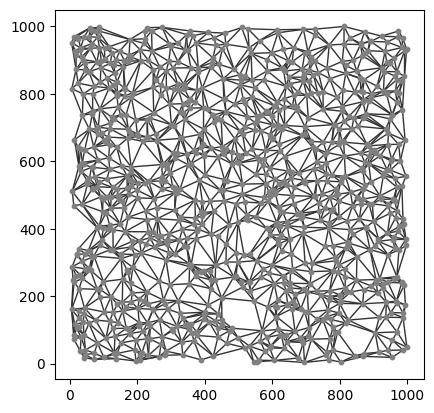

In [25]:
# imports and seed setting
import spacenet as sn
import numpy as np
np.random.seed(42)

# generate a set of random points
points = np.random.rand(1000,2)*1000

# construct a spatial network
spatial_net = sn.utils.spatial_network_from_points(points,max_edge_distance=100)

# plot the network
sn.utils.plot_spatial_network(spatial_net)

Suppose we would like to partition this spatial network into four contiguous regions with approximately equal edge volume. This can be achieved using the `compact_volume_partition()` function.

At a high level, the algorithm partitions the network into `k` connected communities while jointly optimising two objectives: balancing the total edge volume assigned to each partition and promoting spatial compactness by minimising the network distance between nodes and their partition medoid. The optimisation iteratively refines the partition until no single node can be reassigned to improve the combined objective, or until the maximum number of iterations is reached.

The function returns a `Partition` object that stores the resulting partition assignment together with additional information about the optimisation (similar to a cluster object if you've ever used scikit-learn for clustering). This object can be used directly for visualisation or as input to downstream analysis functions throughout SpaceNet.

Let's apply the algorithm to our example spatial network and generate four partitions by setting `k=4`.


In [9]:
# partition the spatial network using compact-volume-balanced method - choosing 4 partitions (k=4)
partition_output = sn.partition.compact_volume_partition(spatial_net,k=4)

# print out the partition_output object and it's properties
print(partition_output.__annotations__)

{'labels': 'Dict', 'community_lengths': 'Dict[int, float]', 'community_cut_lengths': 'Dict[int, float]', 'community_volumes': 'Dict[int, float]', 'medoids': 'Dict[int, object]', 'T': 'float', 'k': 'int', 'objective': 'float', 'compactness': 'float', 'volume_penalty': 'float', 'total_cut_length': 'float', 'moves': 'int', 'iterations': 'int', 'objective_values': 'List[float]'}


The returned `Partition` object stores a range of information describing the resulting partitioning, including the volume of each partition, compactness metrics, and other summary statistics.

One of its most useful attributes is `partition_output.labels`, which is a dictionary mapping each node ID to its assigned partition. Let's inspect these assignments.

In [10]:
# grab the labels from the partition
part_labels_dict = partition_output.labels

# print out the dictionary of labels
print(part_labels_dict)

{np.int64(0): 3, np.int64(1): 0, np.int64(2): 1, np.int64(3): 3, np.int64(4): 0, np.int64(5): 3, np.int64(6): 2, np.int64(7): 1, np.int64(8): 3, np.int64(9): 1, np.int64(10): 2, np.int64(11): 1, np.int64(12): 3, np.int64(13): 3, np.int64(14): 2, np.int64(15): 2, np.int64(16): 3, np.int64(17): 0, np.int64(18): 1, np.int64(19): 2, np.int64(20): 3, np.int64(21): 3, np.int64(22): 3, np.int64(23): 3, np.int64(24): 2, np.int64(25): 0, np.int64(26): 0, np.int64(27): 0, np.int64(28): 1, np.int64(29): 1, np.int64(30): 1, np.int64(31): 2, np.int64(32): 3, np.int64(33): 3, np.int64(34): 3, np.int64(35): 2, np.int64(36): 3, np.int64(37): 0, np.int64(38): 2, np.int64(39): 1, np.int64(40): 0, np.int64(41): 1, np.int64(42): 1, np.int64(43): 0, np.int64(44): 2, np.int64(45): 3, np.int64(46): 0, np.int64(47): 2, np.int64(48): 1, np.int64(49): 1, np.int64(50): 3, np.int64(51): 3, np.int64(52): 2, np.int64(53): 3, np.int64(54): 1, np.int64(55): 1, np.int64(56): 0, np.int64(57): 0, np.int64(58): 2, np.int

To inspect the resulting partitioning, we can add the partition assignments as node labels and visualise them on the spatial network.

(<Figure size 640x480 with 2 Axes>, <Axes: >)

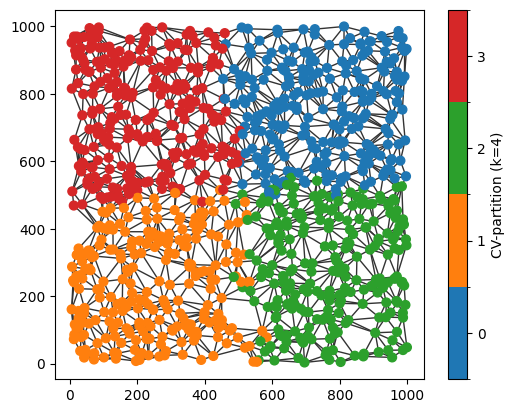

In [11]:
# add the partition labels as node labels 
sn.utils.add_node_labels(spatial_net,list(part_labels_dict.values()),node_label_name='CV-partition (k=4)',nodes=list(part_labels_dict.keys()))

# plot the network
sn.utils.plot_spatial_network(spatial_net,marker_size=40,node_label_name='CV-partition (k=4)')

Visually, the partitions appear both compact and similar in size. We can verify this by inspecting the summary statistics stored in the `Partition` object.


In [21]:
coef_var_vols = np.std(list(partition_output.community_volumes.values()))/np.mean(list(partition_output.community_volumes.values()))*100

print('Percentage Coefficient of Variation in Partition Volumes:', np.round(coef_var_vols,2),'%')

Percentage Coefficient of Variation in Partition Volumes: 0.75 %


The coefficient of variation of the partition volumes is just 0.75%, indicating that the algorithm has produced partitions with highly uniform edge volumes.

Like all SpaceNet functionality, the compact, volume-balanced partitioning algorithm is not restricted to two-dimensional networks. Let's now apply it to a three-dimensional spatial network.

In [26]:
# retreive example dataset points
cylinder_df = sn.datasets.load_dataset('cylinder')
cylinder_points = cylinder_df[['x','y','z']].to_numpy()

# construct a spatial network
cylinder_sn = sn.utils.spatial_network_from_points(cylinder_points,max_edge_distance=50)

# partition the spatial network with 6 partitions
cyl_part_output = sn.partition.compact_volume_partition(cylinder_sn,k=6)

# add as labels to visualise and/or query
sn.utils.add_node_labels(cylinder_sn,list(cyl_part_output.labels.values()),node_label_name='CV-partition (k=6)',nodes=list(cyl_part_output.labels.keys()))

# again, let's check the volumes are consistent 
coef_var_vols = np.std(list(cyl_part_output.community_volumes.values()))/np.mean(list(cyl_part_output.community_volumes.values()))*100
print('Percentage Coefficient of Variation in Partition Volumes:', np.round(coef_var_vols,2),'%')


Percentage Coefficient of Variation in Partition Volumes: 0.3 %


Once again, the partition volumes are highly consistent, with a coefficient of variation of less than **0.5%**. We can visualise the resulting partitions on the spatial network in the same way as before.


(<Figure size 1000x800 with 2 Axes>, <Axes3D: >)

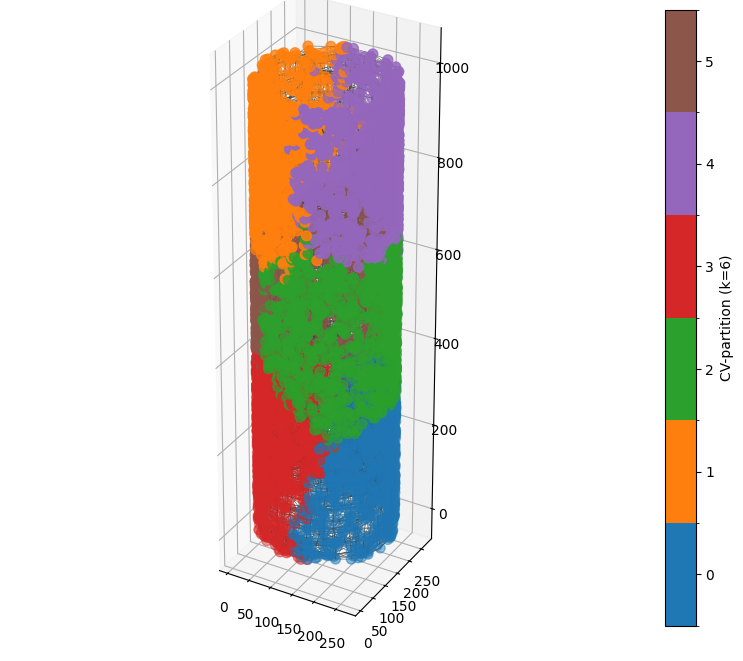

In [23]:
# Tip: you can interact with matplotlib plots in a notebook using the widget backend
# Uncomment the next line for this
#%matplotlib widget

# plot the network
sn.utils.plot_spatial_network(cylinder_sn,edge_width=0.3,node_label_name='CV-partition (k=6)',marker_size=50)

The resulting partitions remain contiguous and compact on the cylindrical surface, demonstrating that the algorithm naturally extends to three-dimensional spatial networks while preserving the desired properties of a spatial tiling.

This tutorial has introduced the practical use of the compact, volume-balanced partitioning algorithm. There are several parameters that can be adjusted to suit different applications. For example, the number of partitions can be specified directly using `k`, or inferred by providing a target partition volume `T`. The trade-off between spatial compactness and volume balance is controlled by `alpha`: values of `alpha` close to **0** prioritise compactness, whereas values close to **1** prioritise equal partition volumes. Exploring these parameters can help generate partitions that best match the characteristics of your spatial network.

For a complete description of the available parameters and their behaviour, see the documentation for `compact_volume_partition()`.